# Temporal Community Detection — pipeline walkthrough

Step-by-step trace of `04_run_community_detection.py` using **leidenalg** and the **supra-adjacency** graph.
Runs on a single scan (20 windows) so every intermediate object can be inspected.

Pipeline stages:
1. Read one 16×16 correlation matrix (CSV)
2. Convert to a sparse `igraph` Graph (16 nodes, positive edges only)
3. Load *N* windows → list of *N* graphs
4. Assemble one **supra-adjacency graph** (T×N nodes, intra + interslice edges)
5. Run `leidenalg.find_partition` → flat membership vector
6. Reshape → (T, N) matrix → count switches → flexibility
7. Average over multiple runs


In [1]:
import re, os, time
from pathlib import Path
from glob import glob
import warnings; warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import igraph as ig
import leidenalg as la
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ── paths ──────────────────────────────────────────────────────────────
CWD = Path.cwd()
SCRIPT_DIR = CWD if CWD.name == 'scripts' else CWD / 'scripts'
CONNECTIVITY_DIR = SCRIPT_DIR / 'window_connectivity'

# ── parameters ─────────────────────────────────────────────────────────
GAMMA            = 0.1   # CPM resolution: lower → bigger communities
INTERSLICE_WEIGHT = 0.5  # ω: how hard ROIs resist switching communities over time
N_DEBUG_WINDOWS  = 20    # windows to load; keep small so the notebook runs fast
N_RUNS           = 5     # Leiden repetitions; use 100 in the real pipeline

print('Connectivity dir:', CONNECTIVITY_DIR)
print('leidenalg version:', la.version)


Connectivity dir: /home/lucagalli/Projects/Progetto_Gozzi/scripts/window_connectivity
leidenalg version: 0.12.0


---
## Step 1 — Pick one scan

The connectivity directory is organised as `<dataset>/<preproc>/<subject>/<scan>_window_NNNN.csv`.
We grab all window files for the first scan we find and keep the first 20.


In [2]:
all_files = sorted(CONNECTIVITY_DIR.glob('*/*/*/*.csv'))
assert all_files, f'No files found in {CONNECTIVITY_DIR}'

# derive scan prefix from the first file
stem = all_files[0].stem
scan_prefix = stem[:re.search(r'_window_\d+', stem).start()]
scan_files = sorted(f for f in all_files if f.stem.startswith(scan_prefix))
selected = scan_files[:N_DEBUG_WINDOWS]

def window_id(path): return int(re.search(r'_window_(\d+)', path.stem).group(1))

print(f'Scan:              {scan_prefix}')
print(f'Total windows:     {len(scan_files)}')
print(f'Using first:       {len(selected)}')

pd.DataFrame({'window_id': [window_id(f) for f in selected],
              'filename':  [f.name for f in selected]})


Scan:              sub-ag230908a_EXP_bold_parcellated
Total windows:     650
Using first:       20


,window_id,filename
0,8,sub-ag230908a_EXP_bold_parcellated_window_0008...
1,9,sub-ag230908a_EXP_bold_parcellated_window_0009...
2,10,sub-ag230908a_EXP_bold_parcellated_window_0010...
3,11,sub-ag230908a_EXP_bold_parcellated_window_0011...
4,12,sub-ag230908a_EXP_bold_parcellated_window_0012...
5,13,sub-ag230908a_EXP_bold_parcellated_window_0013...
6,14,sub-ag230908a_EXP_bold_parcellated_window_0014...
7,15,sub-ag230908a_EXP_bold_parcellated_window_0015...
8,16,sub-ag230908a_EXP_bold_parcellated_window_0016...
9,17,sub-ag230908a_EXP_bold_parcellated_window_0017...


---
## Step 2 — Read one connectivity matrix

`read_window` loads the 16×16 Pearson correlation CSV and zeros the diagonal.
Values outside the diagonal are correlations between ROI pairs inside this 35-TR window.


In [3]:
def read_window(path):
    df = pd.read_csv(path, index_col=0)
    for col in df.columns:
        df.loc[col, col] = 0.0   # no self-edges
    return df

df0 = read_window(selected[0])
print(f'Shape:   {df0.shape}')
print(f'ROIs:    {list(df0.columns)}')
print(f'Diagonal: {df0.values.diagonal().tolist()}  (all zeroed)')
df0.round(3)


Shape:   (16, 16)
ROIs:    ['DMNa', 'DMNp', 'SAL', 'OLF', 'STR', 'AUD', 'VIS', 'TH', 'MOp', 'SSp', 'SSs', 'HCa', 'SUB', 'CTXsp', 'BF', 'HY']
Diagonal: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]  (all zeroed)


,DMNa,DMNp,SAL,OLF,STR,AUD,VIS,TH,MOp,SSp,SSs,HCa,SUB,CTXsp,BF,HY
DMNa,0.000,0.005,0.380,-0.195,-0.019,0.483,0.384,0.197,0.680,0.454,0.769,0.318,-0.027,0.089,-0.304,-0.164
DMNp,0.005,0.000,0.637,0.777,0.204,0.458,0.516,-0.031,0.555,0.016,0.320,0.336,-0.041,0.360,0.758,-0.223
SAL,0.380,0.637,0.000,0.779,0.011,0.328,0.180,-0.191,0.484,0.342,0.442,0.211,-0.404,0.679,0.503,0.071
OLF,-0.195,0.777,0.779,0.000,0.057,0.087,0.031,-0.348,0.239,0.119,0.057,0.056,-0.386,0.668,0.769,0.031
STR,-0.019,0.204,0.011,0.057,0.000,0.586,0.474,0.729,0.082,0.684,0.443,0.782,0.426,0.287,0.495,-0.373
AUD,0.483,0.458,0.328,0.087,0.586,0.000,0.888,0.792,0.387,0.445,0.890,0.944,0.604,0.378,0.171,-0.695
VIS,0.384,0.516,0.180,0.031,0.474,0.888,0.000,0.691,0.501,0.196,0.688,0.825,0.722,0.114,0.119,-0.507
TH,0.197,-0.031,-0.191,-0.348,0.729,0.792,0.691,0.000,-0.075,0.405,0.597,0.891,0.827,0.088,-0.056,-0.600
MOp,0.680,0.555,0.484,0.239,0.082,0.387,0.501,-0.075,0.000,0.309,0.551,0.219,-0.159,0.041,0.249,-0.027
SSp,0.454,0.016,0.342,0.119,0.684,0.445,0.196,0.405,0.309,0.000,0.636,0.571,-0.024,0.555,0.270,-0.246


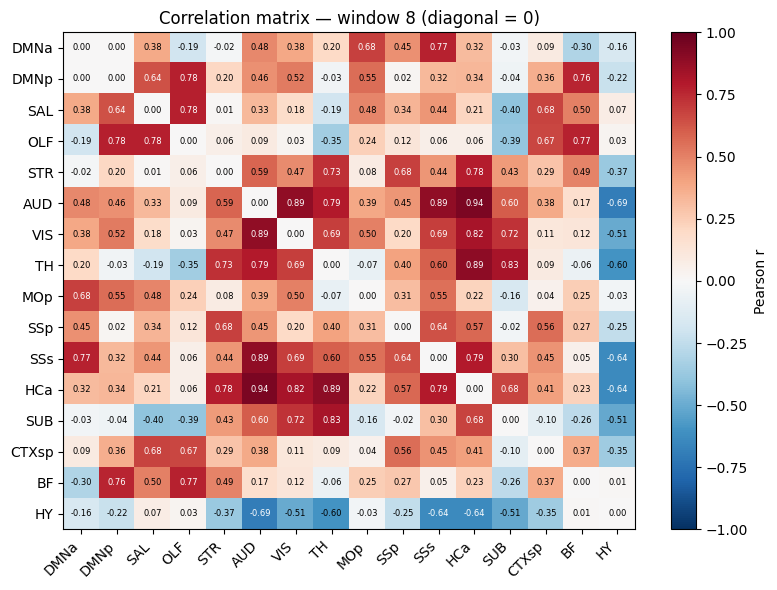

In [4]:
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(df0.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(df0.columns))); ax.set_xticklabels(df0.columns, rotation=45, ha='right')
ax.set_yticks(range(len(df0.index)));   ax.set_yticklabels(df0.index)
for i in range(len(df0)):
    for j in range(len(df0.columns)):
        ax.text(j, i, f'{df0.values[i,j]:.2f}', ha='center', va='center', fontsize=6,
                color='white' if abs(df0.values[i,j]) > 0.6 else 'black')
plt.colorbar(im, ax=ax, label='Pearson r')
ax.set_title(f'Correlation matrix — window {window_id(selected[0])} (diagonal = 0)')
plt.tight_layout(); plt.show()


---
## Step 3 — Build a per-window `igraph` graph

`build_igraph` takes the correlation matrix and creates a sparse weighted graph.
Negative correlations are dropped entirely; only the upper triangle is processed
(the matrix is symmetric, so each pair appears once).

```
vertex i  =  ROI column i
edge (i,j)  weight  =  Pearson r between ROI_i and ROI_j  (positive only)
```


In [5]:
def build_igraph(df):
    roi_names = list(df.columns)
    graph = ig.Graph()
    graph.add_vertices(len(roi_names))
    graph.vs['name'] = roi_names
    corr_array = df.to_numpy(dtype=float)
    row_indices, col_indices = np.triu_indices(len(roi_names), k=1)
    edge_weights = corr_array[row_indices, col_indices]
    positive_mask = edge_weights > 0
    graph.add_edges(list(zip(row_indices[positive_mask].tolist(),
                             col_indices[positive_mask].tolist())))
    graph.es['weight'] = edge_weights[positive_mask].tolist()
    return graph

g0 = build_igraph(df0)
print(f'Vertices: {g0.vcount()}  (one per ROI)')
print(f'Edges:    {g0.ecount()}  (positive correlations only; {120 - g0.ecount()} negative/zero pairs dropped)')
print(f'Mean edge weight: {np.mean(g0.es["weight"]):.4f}')

# Show how vertex indices map back to ROI names and edge weights
rows = []
for edge in g0.es:
    src, tgt = edge.tuple
    rows.append({'src_idx': src, 'src_roi': g0.vs[src]['name'],
                 'tgt_idx': tgt, 'tgt_roi': g0.vs[tgt]['name'],
                 'weight': round(edge['weight'], 4)})
pd.DataFrame(rows).head(15)


Vertices: 16  (one per ROI)
Edges:    92  (positive correlations only; 28 negative/zero pairs dropped)
Mean edge weight: 0.4204


,src_idx,src_roi,tgt_idx,tgt_roi,weight
0,0,DMNa,1,DMNp,0.0047
1,0,DMNa,2,SAL,0.3796
2,0,DMNa,5,AUD,0.4834
3,0,DMNa,6,VIS,0.3839
4,0,DMNa,7,TH,0.1969
5,0,DMNa,8,MOp,0.6803
6,0,DMNa,9,SSp,0.4543
7,0,DMNa,10,SSs,0.7694
8,0,DMNa,11,HCa,0.3176
9,0,DMNa,13,CTXsp,0.0894


---
## Step 4 — Load all *N* windows

The loading loop calls `read_window` + `build_igraph` for each of the 20 windows.
Edge count varies per window because different fractions of correlations are positive.


In [6]:
graphs = []
node_names = None
for f in selected:
    df = read_window(f)
    if node_names is None:
        node_names = list(df.columns)
    graphs.append(build_igraph(df))

n_windows    = len(graphs)
n_nodes      = len(node_names)    # 16
n_transitions = n_windows - 1     # 19

summary = pd.DataFrame({
    'window': list(range(n_windows)),
    'window_id': [window_id(f) for f in selected],
    'n_edges': [g.ecount() for g in graphs],
    'mean_weight': [round(np.mean(g.es['weight']), 4) if g.ecount() else 0 for g in graphs],
})
print(f'{n_windows} graphs loaded — {n_nodes} nodes each')
summary


20 graphs loaded — 16 nodes each


,window,window_id,n_edges,mean_weight
0,0,8,92,0.4204
1,1,9,91,0.4205
2,2,10,92,0.4045
3,3,11,86,0.4230
4,4,12,82,0.4103
5,5,13,74,0.4133
6,6,14,71,0.4140
7,7,15,72,0.3929
8,8,16,68,0.3962
9,9,17,68,0.3684


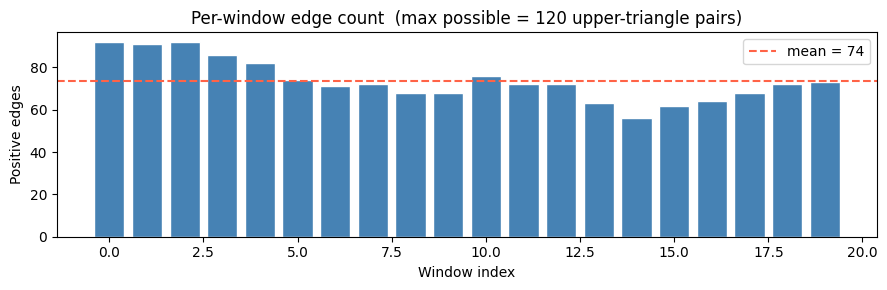

In [7]:
fig, ax = plt.subplots(figsize=(9, 3))
ax.bar(summary['window'], summary['n_edges'], color='steelblue', edgecolor='white')
ax.axhline(summary['n_edges'].mean(), color='tomato', linestyle='--', label=f'mean = {summary["n_edges"].mean():.0f}')
ax.set_xlabel('Window index'); ax.set_ylabel('Positive edges')
ax.set_title('Per-window edge count  (max possible = 120 upper-triangle pairs)')
ax.legend(); plt.tight_layout(); plt.show()


---
## Step 5 — Build the supra-adjacency graph

All 20 windows are packed into **one** graph.  
Each window gets a contiguous block of 16 vertices:

```
vertex  t*16 + i  =  ROI i in window t

window 0  → vertices   0 –  15  (DMNa=0, DMNp=1, ..., HY=15)
window 1  → vertices  16 –  31
window 2  → vertices  32 –  47
...        ...
window 19 → vertices 304 – 319
```

**Intra-window edges** — correlation edges for window *t*, offset by `t*16`.  
**Interslice edges** — `(t*16+i) — ((t+1)*16+i)` with weight ω for every ROI *i* and every adjacent window pair.  
These are the temporal glue: they penalise a ROI for landing in a different community than its copy one window earlier.


In [8]:
intra_sources, intra_targets, intra_weights_list = [], [], []
for window_idx, window_graph in enumerate(graphs):
    vertex_offset = window_idx * n_nodes
    for edge in window_graph.es:
        intra_sources.append(vertex_offset + edge.source)
        intra_targets.append(vertex_offset + edge.target)
        intra_weights_list.append(edge['weight'])

window_indices = np.repeat(np.arange(n_transitions), n_nodes)
roi_indices    = np.tile(np.arange(n_nodes), n_transitions)
interslice_src = (window_indices * n_nodes + roi_indices).tolist()
interslice_tgt = ((window_indices + 1) * n_nodes + roi_indices).tolist()

supra = ig.Graph()
supra.add_vertices(n_windows * n_nodes)
supra.add_edges(list(zip(intra_sources + interslice_src,
                          intra_targets + interslice_tgt)))
supra.es['weight'] = intra_weights_list + [INTERSLICE_WEIGHT] * len(interslice_src)

print(f'Supra-graph')
print(f'  vertices : {supra.vcount():,}   ({n_windows} windows × {n_nodes} ROIs)')
print(f'  edges    : {supra.ecount():,}')
print(f'    intra-window : {len(intra_sources):,}')
print(f'    interslice   : {len(interslice_src):,}   ({n_transitions} transitions × {n_nodes} ROIs, weight={INTERSLICE_WEIGHT})')


Supra-graph
  vertices : 320   (20 windows × 16 ROIs)
  edges    : 1,778
    intra-window : 1,474
    interslice   : 304   (19 transitions × 16 ROIs, weight=0.5)


In [9]:
# Show vertex index → (window, ROI) mapping for the first 3 windows
rows = []
for w in range(3):
    for i, roi in enumerate(node_names):
        rows.append({'vertex_id': w * n_nodes + i, 'window': w, 'roi': roi})
print('Vertex layout — first 3 windows:')
pd.DataFrame(rows)


Vertex layout — first 3 windows:


,vertex_id,window,roi
0,0,0,DMNa
1,1,0,DMNp
2,2,0,SAL
3,3,0,OLF
4,4,0,STR
5,5,0,AUD
6,6,0,VIS
7,7,0,TH
8,8,0,MOp
9,9,0,SSp


In [10]:
# Show interslice chain for DMNa (roi_index=0) across all window transitions
dmna_rows = []
for t in range(n_transitions):
    dmna_rows.append({
        'transition': f'win {t} → win {t+1}',
        'from_vertex': t * n_nodes,
        'to_vertex':   (t + 1) * n_nodes,
        'weight': INTERSLICE_WEIGHT,
    })
print(f'Interslice chain for DMNa (roi_index=0) — {n_transitions} edges:')
pd.DataFrame(dmna_rows)


Interslice chain for DMNa (roi_index=0) — 19 edges:


,transition,from_vertex,to_vertex,weight
0,win 0 → win 1,0,16,0.5
1,win 1 → win 2,16,32,0.5
2,win 2 → win 3,32,48,0.5
3,win 3 → win 4,48,64,0.5
4,win 4 → win 5,64,80,0.5
5,win 5 → win 6,80,96,0.5
6,win 6 → win 7,96,112,0.5
7,win 7 → win 8,112,128,0.5
8,win 8 → win 9,128,144,0.5
9,win 9 → win 10,144,160,0.5


---
## Step 6 — Run Leiden (`find_partition`)

A single `find_partition` call over the whole supra-graph.  
The CPM objective pulls correlated ROIs into the same community within each window block,
while the ω interslice edges penalise switching communities between adjacent windows.

Output: `partition.membership` — a flat list of length `T×N = 320`.
Entry `t*16 + i` is the community label of ROI *i* in window *t*.


In [11]:
partition = la.find_partition(
    supra,
    la.CPMVertexPartition,
    weights='weight',
    resolution_parameter=GAMMA,
    seed=42,
)

n_communities = len(set(partition.membership))
print(f'Communities found : {n_communities}')
print(f'Membership length : {len(partition.membership)}  ({n_windows}×{n_nodes})')
print()
print('First 32 labels (window 0 and window 1):')
print('  win 0:', partition.membership[:16])
print('  win 1:', partition.membership[16:32])
print('       ', node_names, '  ← ROI names')


Communities found : 40
Membership length : 320  (20×16)

First 32 labels (window 0 and window 1):
  win 0: [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 39]
  win 1: [3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 39]
        ['DMNa', 'DMNp', 'SAL', 'OLF', 'STR', 'AUD', 'VIS', 'TH', 'MOp', 'SSp', 'SSs', 'HCa', 'SUB', 'CTXsp', 'BF', 'HY']   ← ROI names


---
## Step 7 — Reshape membership and inspect

Because vertices are laid out as `t*N+i`, a simple `reshape(T, N)` recovers
the time × ROI matrix — no index lookup needed.

Row *t* = community labels of all 16 ROIs in window *t*.  
Column *i* = community labels of ROI *i* across all 20 windows.


In [12]:
membership_matrix = np.array(partition.membership, dtype=np.int32).reshape(n_windows, n_nodes)
print(f'Shape: {membership_matrix.shape}  (windows × ROIs)')

membership_df = pd.DataFrame(
    membership_matrix,
    index=[f'win {i}' for i in range(n_windows)],
    columns=node_names,
)
membership_df


Shape: (20, 16)  (windows × ROIs)


,DMNa,DMNp,SAL,OLF,STR,AUD,VIS,TH,MOp,SSp,SSs,HCa,SUB,CTXsp,BF,HY
win 0,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,39
win 1,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,39
win 2,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
win 3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
win 4,9,9,9,19,9,9,9,9,9,9,9,9,9,19,9,19
win 5,5,5,5,19,5,5,5,5,5,5,5,5,5,19,5,19
win 6,4,4,4,20,4,4,4,4,4,4,4,4,4,20,4,20
win 7,8,8,8,20,8,8,8,8,8,8,8,8,8,20,8,20
win 8,18,14,14,14,14,18,18,18,14,14,18,18,18,14,14,14
win 9,17,15,15,15,15,17,17,17,15,15,17,17,17,15,15,15


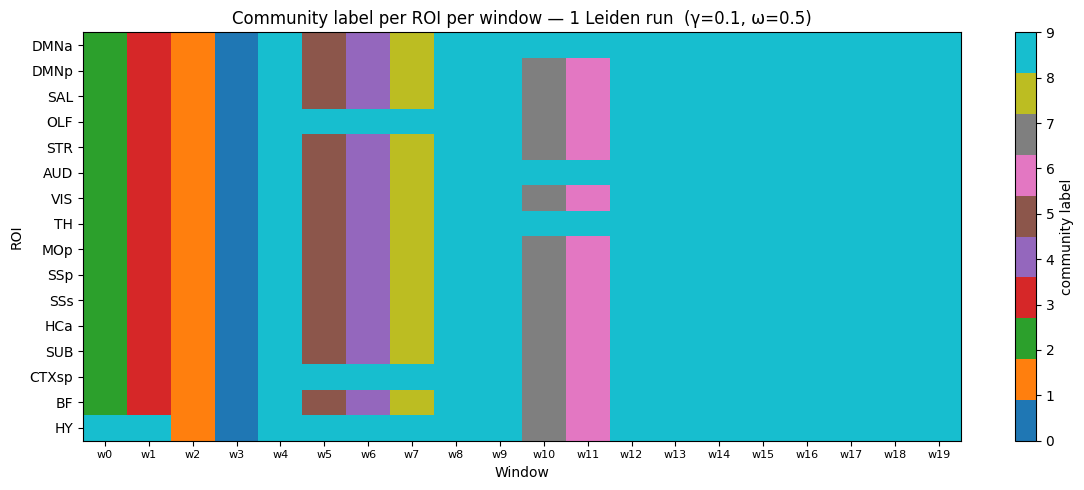

Stable ROI = same colour across all windows.
Flexible ROI = colour changes between windows.


In [13]:
# Heatmap: rows = ROIs, columns = windows
# Each cell is the community label for that ROI at that window.
# Stable ROIs have constant colour across a row; flexible ones flicker.
cmap = plt.cm.get_cmap('tab10', 10)
fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(membership_df.T.values, cmap=cmap, vmin=0, vmax=9, aspect='auto')
ax.set_xticks(range(n_windows)); ax.set_xticklabels([f'w{i}' for i in range(n_windows)], fontsize=8)
ax.set_yticks(range(n_nodes));   ax.set_yticklabels(node_names)
plt.colorbar(im, ax=ax, label='community label', ticks=range(10))
ax.set_xlabel('Window'); ax.set_ylabel('ROI')
ax.set_title(f'Community label per ROI per window — 1 Leiden run  (γ={GAMMA}, ω={INTERSLICE_WEIGHT})')
plt.tight_layout(); plt.show()
print('Stable ROI = same colour across all windows.')
print('Flexible ROI = colour changes between windows.')


---
## Step 8 — Compute flexibility (one run)

Compare each row with the row above it.  
A True means that ROI changed community at that transition.  
Sum column-wise → total switches per ROI.  Divide by T-1 → fraction in [0, 1].

```
switches = sum(membership_matrix[1:] != membership_matrix[:-1], axis=0)  # shape (16,)
flexibility = switches / (T - 1)
```


In [14]:
switches    = np.sum(membership_matrix[1:] != membership_matrix[:-1], axis=0)
flexibility = switches / n_transitions

flex_df = pd.DataFrame({
    'ROI':          node_names,
    'switches':     switches,
    'transitions':  n_transitions,
    'flexibility':  flexibility.round(4),
}).sort_values('flexibility', ascending=False).reset_index(drop=True)
flex_df


,ROI,switches,transitions,flexibility
0,DMNp,19,19,1.0000
1,STR,19,19,1.0000
2,VIS,19,19,1.0000
3,HCa,19,19,1.0000
4,SUB,19,19,1.0000
5,BF,19,19,1.0000
6,SSs,19,19,1.0000
7,SAL,18,19,0.9474
8,MOp,18,19,0.9474
9,SSp,18,19,0.9474


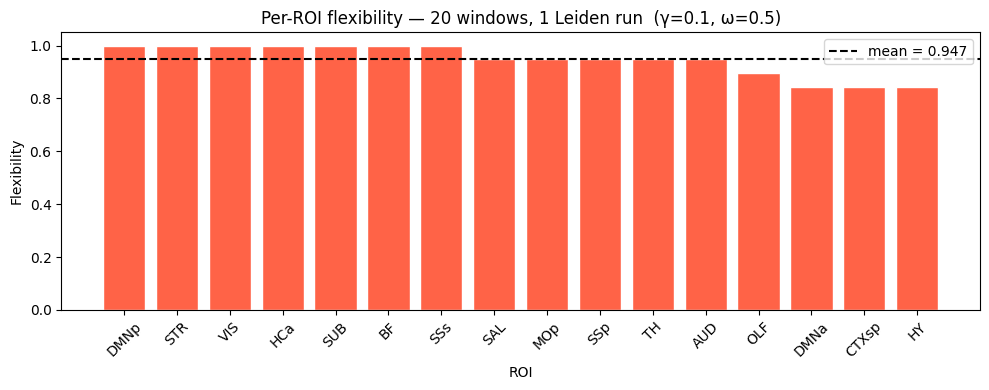

In [15]:
fig, ax = plt.subplots(figsize=(10, 4))
colours = ['tomato' if v > 0.5 else 'steelblue' for v in flex_df['flexibility']]
ax.bar(flex_df['ROI'], flex_df['flexibility'], color=colours, edgecolor='white')
ax.axhline(flex_df['flexibility'].mean(), color='black', linestyle='--',
           label=f'mean = {flex_df["flexibility"].mean():.3f}')
ax.set_ylim(0, 1.05)
ax.set_xlabel('ROI'); ax.set_ylabel('Flexibility')
ax.set_title(f'Per-ROI flexibility — {N_DEBUG_WINDOWS} windows, 1 Leiden run  (γ={GAMMA}, ω={INTERSLICE_WEIGHT})')
ax.tick_params(axis='x', rotation=45)
ax.legend(); plt.tight_layout(); plt.show()


---
## Step 9 — Average over multiple runs

Leiden is non-deterministic. Running it once gives one valid partition,
but the community labels can vary between runs.  
We repeat `N_RUNS` times with different seeds and average the flexibility values.

This is what the full pipeline does with `N_RUNS=100`.  
Here we use `N_RUNS=5` to keep the notebook fast.


In [16]:
all_flex = []
for seed in range(N_RUNS):
    part = la.find_partition(supra, la.CPMVertexPartition,
                              weights='weight', resolution_parameter=GAMMA, seed=seed)
    m  = np.array(part.membership, dtype=np.int32).reshape(n_windows, n_nodes)
    sw = np.sum(m[1:] != m[:-1], axis=0)
    all_flex.append(sw / n_transitions)

mean_flex = np.mean(all_flex, axis=0)
std_flex  = np.std(all_flex,  axis=0)

final_df = pd.DataFrame({
    'Node':       node_names,
    'flexibility': mean_flex.round(4),
    'std':         std_flex.round(4),
    'gamma':      GAMMA,
    'omega':      INTERSLICE_WEIGHT,
    'n_runs':     N_RUNS,
    'n_windows':  n_windows,
}).sort_values('flexibility', ascending=False).reset_index(drop=True)
print(f'{N_RUNS} runs averaged')
final_df


5 runs averaged


,Node,flexibility,std,gamma,omega,n_runs,n_windows
0,VIS,1.0000,0.0000,0.1,0.5,5,20
1,STR,1.0000,0.0000,0.1,0.5,5,20
2,SSs,1.0000,0.0000,0.1,0.5,5,20
3,HCa,1.0000,0.0000,0.1,0.5,5,20
4,BF,1.0000,0.0000,0.1,0.5,5,20
5,SUB,0.9895,0.0211,0.1,0.5,5,20
6,DMNp,0.9895,0.0211,0.1,0.5,5,20
7,MOp,0.9474,0.0000,0.1,0.5,5,20
8,SSp,0.9474,0.0000,0.1,0.5,5,20
9,SAL,0.9368,0.0211,0.1,0.5,5,20


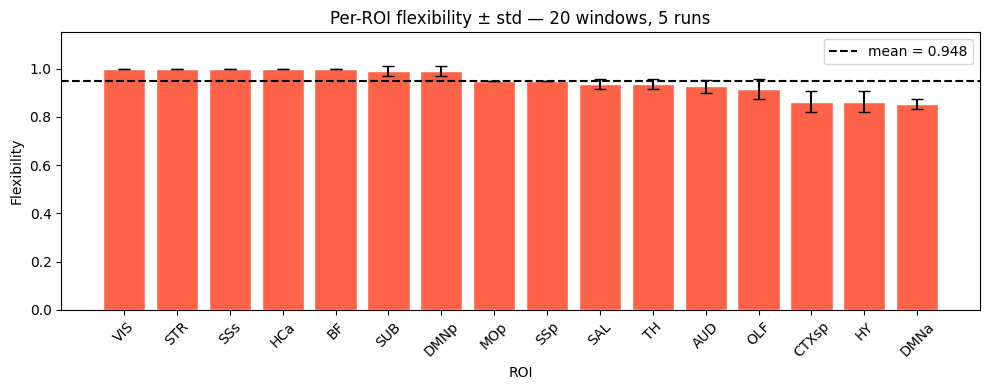

In [17]:
fig, ax = plt.subplots(figsize=(10, 4))
order = final_df['Node'].tolist()
means = final_df['flexibility'].values
stds  = final_df['std'].values
ax.bar(order, means, yerr=stds, capsize=4,
       color=['tomato' if v > 0.5 else 'steelblue' for v in means], edgecolor='white')
ax.axhline(means.mean(), color='black', linestyle='--', label=f'mean = {means.mean():.3f}')
ax.set_ylim(0, 1.15)
ax.set_xlabel('ROI'); ax.set_ylabel('Flexibility')
ax.set_title(f'Per-ROI flexibility ± std — {N_DEBUG_WINDOWS} windows, {N_RUNS} runs')
ax.tick_params(axis='x', rotation=45)
ax.legend(); plt.tight_layout(); plt.show()
